In [1]:
from Configs.config import hyperparams


ModuleNotFoundError: No module named 'Configs'

In [9]:
import tensorflow as tf
import tensorflow_datasets as tfds
from Configs.config import hyperparams

def load_and_preprocess_data(validation_split=0.1):
    # Compute sizes for splits
    train_split = f"train[:{int((1 - validation_split) * 100)}%]"
    val_split = f"train[{int((1 - validation_split) * 100)}%:]"
    
    # Load train, validation, and test splits
    ds_train = tfds.load('mnist', split=train_split, as_supervised=True)
    ds_val = tfds.load('mnist', split=val_split, as_supervised=True)
    ds_test = tfds.load('mnist', split='test', as_supervised=True)

    # Normalization function: scale images to [0, 1]
    def normalize(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    batch_size = hyperparams['batch_size']

    # Preprocess datasets: normalize, shuffle, batch, prefetch
    ds_train = ds_train.map(normalize).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    ds_val = ds_val.map(normalize).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    ds_test = ds_test.map(normalize).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds_train, ds_val, ds_test


ModuleNotFoundError: No module named 'Configs'

Label: 4


2025-10-12 00:05:57.794130: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


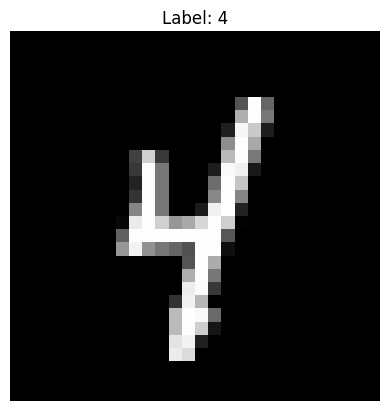

2025-10-12 00:05:57.821970: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# Display one image as example

import matplotlib.pyplot as plt

for image, label in ds_train.take(1):
    # Convert image tensor to numpy array
    img = image.numpy().squeeze()  # remove channel dimension if needed
    
    # Print label
    print("Label:", label.numpy())
    
    # Display the image
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    plt.show()